In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt


n=95
WilcoxonResult(statistic=2568.0, pvalue=0.04741207192983484)
WilcoxonResult(statistic=2760.0, pvalue=0.02334123653722644)


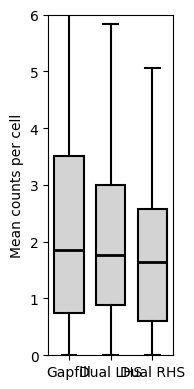

In [2]:
dual_lhs = pd.read_csv('../../2_figure_CL_benchmarking/output/dual_probe_lhs_summary.csv', index_col = 0)
dual_rhs = pd.read_csv('../../2_figure_CL_benchmarking/output/dual_probe_rhs_summary.csv', index_col = 0)
gapfill = pd.read_csv('../../1_figure_CL_proof_of_concept/output/gapfill_betaine_1plex_summary.csv', index_col = 0)

merged_likelihoods = gapfill[['mean_counts']].add_suffix('_gapfill') \
    .join(dual_lhs[['mean_counts']].add_suffix('_dual_lhs')) \
    .join(dual_rhs[['mean_counts']].add_suffix('_dual_rhs'))

prefix = 'mean_counts_'

fig, ax = plt.subplots(figsize=(2,4))
data = [
    merged_likelihoods[prefix + 'gapfill'].dropna(),
    merged_likelihoods[prefix + 'dual_lhs'].dropna(),
    merged_likelihoods[prefix + 'dual_rhs'].dropna()
]

ax.boxplot(
    data,
    tick_labels=[
        'Gapfill',
        'Dual LHS',
        'Dual RHS'
    ],
    patch_artist=True,
    boxprops=dict(facecolor='lightgrey', color='k', linewidth=1.5),
    medianprops=dict(color='k', linewidth=2),
    whiskerprops=dict(color='k', linewidth=1.5),
    capprops=dict(color='k', linewidth=1.5),
    showfliers=False,
    widths=0.7  # Make boxes wider
)
ax.set_ylabel('Mean counts per cell')
ax.set_ylim(0, 6)
ax.grid(False)
plt.tight_layout()

print('n=' + str(len(data[0])))

print(st.wilcoxon(data[0], data[1], alternative='greater'))
print(st.wilcoxon(data[1], data[2], alternative='greater'))

plt.savefig('../plots/mean_counts_gapfill_vs_dual_boxplot.pdf', bbox_inches='tight', dpi=300)

WilcoxonResult(statistic=24.0, pvalue=0.03924560546875)
WilcoxonResult(statistic=52.0, pvalue=0.13166046142578125)
1.053482876715457
31 14 17


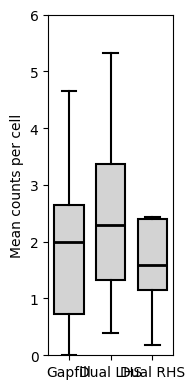

In [3]:
dual = pd.read_csv('../output/0bp_genotyping_betaine_3plex_summary.csv', index_col = 0)
dual_lhs = dual.loc[dual['variant'] == 'lhs'].copy()
dual_rhs = dual.loc[dual['variant'] == 'rhs'].copy()
gapfill = pd.read_csv('../output/gapfill_betaine_3plex_summary.csv', index_col = 0)

merged_likelihoods = gapfill[['mean_counts']].add_suffix('_gapfill') \
    .join(dual_lhs[['mean_counts']].add_suffix('_dual_lhs')) \
    .join(dual_rhs[['mean_counts']].add_suffix('_dual_rhs'))

prefix = 'mean_counts_'

fig, ax = plt.subplots(figsize=(2,4))
data = [
    merged_likelihoods[prefix + 'gapfill'].dropna(),
    merged_likelihoods[prefix + 'dual_lhs'].dropna(),
    merged_likelihoods[prefix + 'dual_rhs'].dropna()
]
ax.boxplot(
    data,
    tick_labels=[
        'Gapfill',
        'Dual LHS',
        'Dual RHS'
    ],
    patch_artist=True,
    boxprops=dict(facecolor='lightgrey', color='k', linewidth=1.5),
    medianprops=dict(color='k', linewidth=2),
    whiskerprops=dict(color='k', linewidth=1.5),
    capprops=dict(color='k', linewidth=1.5),
    showfliers=False,
    widths=0.7  # Make boxes wider
)
ax.set_ylabel('Mean counts per cell')
ax.set_ylim(0, 6)
ax.grid(False)
plt.tight_layout()

print(st.wilcoxon(data[0].loc[data[1].index], data[1], alternative='less'))
print(st.wilcoxon(data[0].loc[data[2].index], data[2], alternative='less'))

print((data[1] / data[0].loc[data[1].index]).median())

print(len(data[0]), len(data[1]), len(data[2]))
plt.savefig('../plots/mean_counts_gapfill_vs_dual_boxplot_3plex.pdf', bbox_inches='tight', dpi=300)